In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             ConfusionMatrixDisplay, classification_report)

sns.set_style("whitegrid")

In [126]:
penguins = sns.load_dataset("penguins").dropna()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [127]:
penguins.info()

<class 'pandas.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    str    
 1   island             333 non-null    str    
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 26.7 KB


In [128]:
penguins.shape

(333, 7)

In [129]:
penguins.species.value_counts()

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

Numerical columns - bill_length_mm | bill_depth_mm | flipper_length_mm | body_mass_g

Categorical columns - species | island | sex

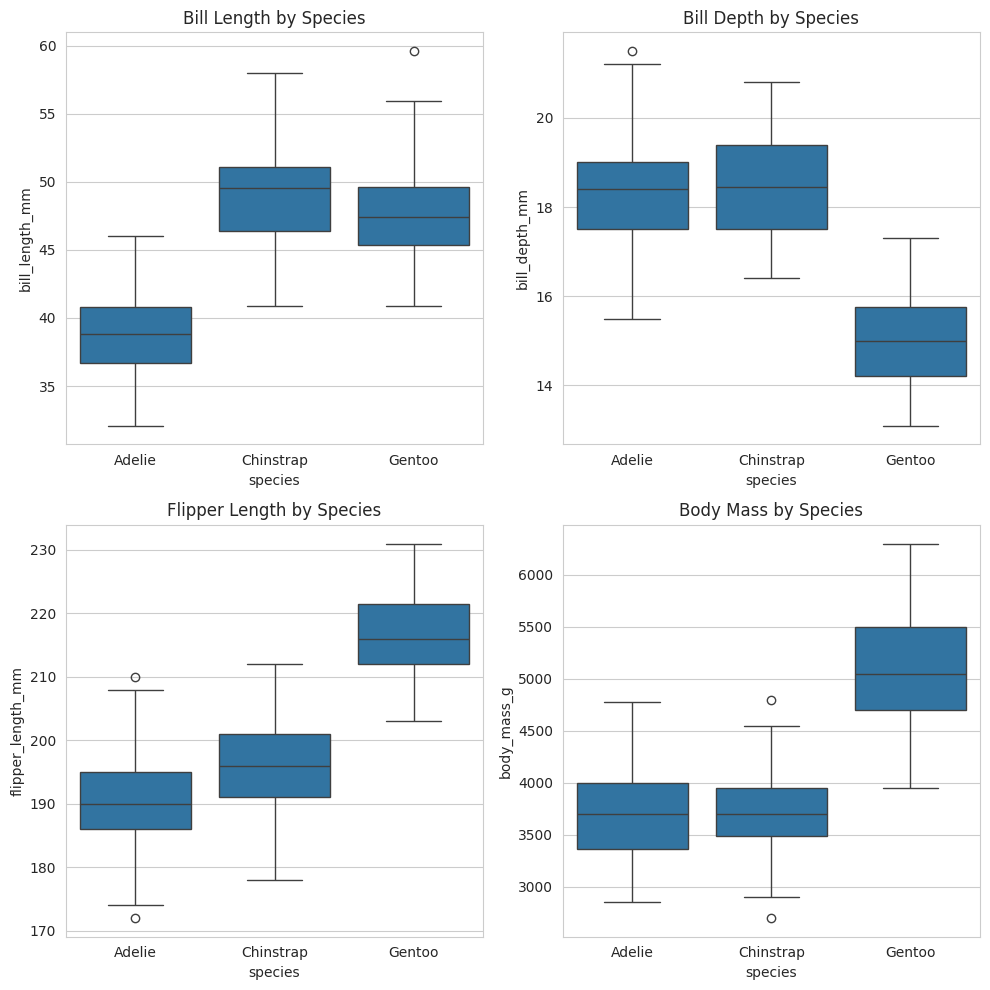

In [130]:
fig, axes = plt.subplots(2,2,figsize=(10, 10))

axes[0, 0].set_title("Bill Length by Species")
sns.boxplot(x="species", y="bill_length_mm", data=penguins, ax=axes[0, 0])

axes[0, 1].set_title("Bill Depth by Species")
sns.boxplot(x="species", y="bill_depth_mm", data=penguins, ax=axes[0, 1])

axes[1, 0].set_title("Flipper Length by Species")
sns.boxplot(x="species", y="flipper_length_mm", data=penguins, ax=axes[1, 0])

axes[1, 1].set_title("Body Mass by Species")
sns.boxplot(x="species", y="body_mass_g", data=penguins, ax=axes[1, 1])

plt.tight_layout()
plt.show()  

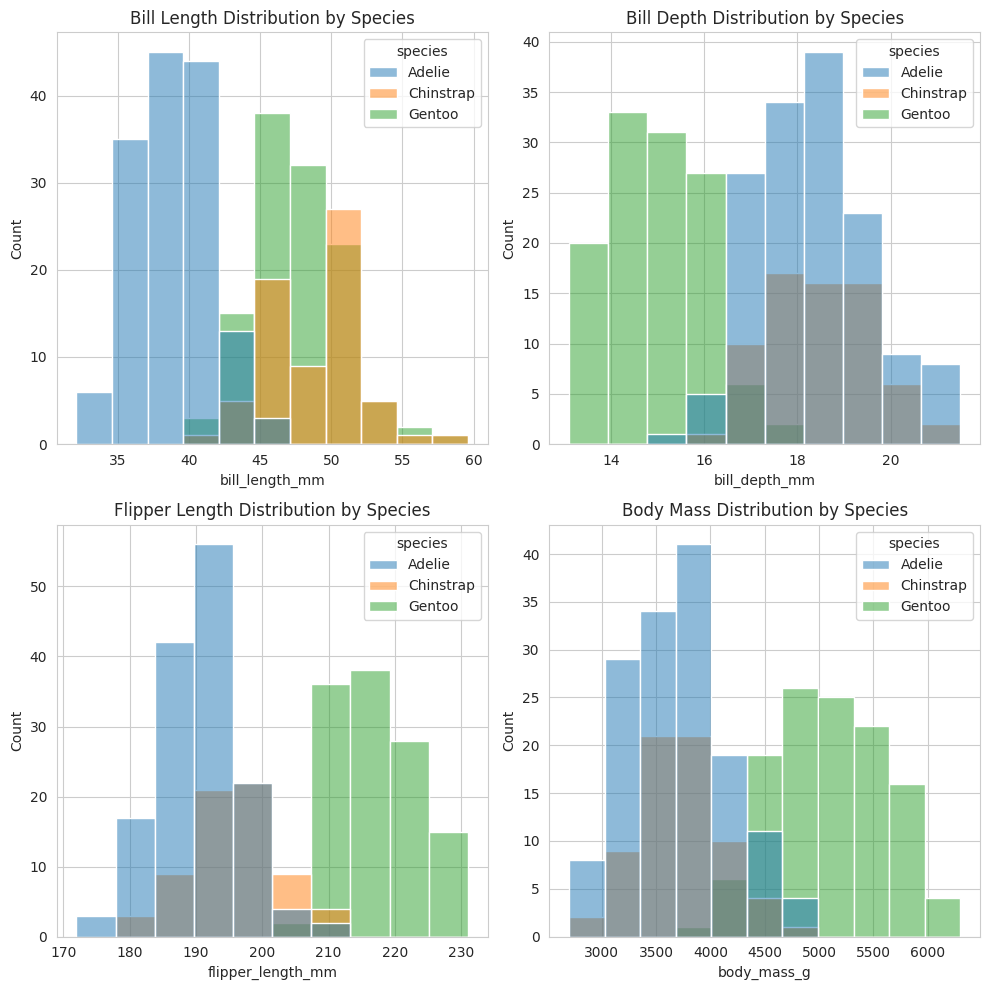

In [131]:
fig, axes = plt.subplots(2,2,figsize=(10, 10))
axes[0, 0].set_title("Bill Length Distribution by Species")
sns.histplot(x="bill_length_mm", hue="species", data=penguins, ax=axes[0, 0], bins='auto')

axes[0, 1].set_title("Bill Depth Distribution by Species")
sns.histplot(x="bill_depth_mm", hue="species", data=penguins, ax=axes[0, 1], bins='auto')

axes[1, 0].set_title("Flipper Length Distribution by Species")
sns.histplot(x="flipper_length_mm", hue="species", data=penguins, ax=axes[1, 0], bins='auto')   

axes[1, 1].set_title("Body Mass Distribution by Species")
sns.histplot(x="body_mass_g", hue="species", data=penguins, ax=axes[1, 1], bins='auto')

plt.tight_layout()
plt.show()

In [132]:
X = penguins.drop("species", axis=1)
y = penguins["species"]

In [133]:
penguins.species.unique()

<ArrowStringArray>
['Adelie', 'Chinstrap', 'Gentoo']
Length: 3, dtype: str

In [134]:
y = LabelEncoder().fit_transform(y)
X = pd.get_dummies(X, columns=["island", "sex"], drop_first=True)
X.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_Male
0,39.1,18.7,181.0,3750.0,False,True,True
1,39.5,17.4,186.0,3800.0,False,True,False
2,40.3,18.0,195.0,3250.0,False,True,False
4,36.7,19.3,193.0,3450.0,False,True,False
5,39.3,20.6,190.0,3650.0,False,True,True


In [135]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [136]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) 

In [137]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_log_reg)
precision = precision_score(y_test, y_pred_log_reg, average='weighted')
recall = recall_score(y_test, y_pred_log_reg, average='weighted')
f1 = f1_score(y_test, y_pred_log_reg, average='weighted')

print(f"""Logistic Regression
Accuracy: {accuracy:.4f}
Precision: {precision:.4f}
Recall: {recall:.4f}
F1 Score: {f1:.4f}""")

Logistic Regression
Accuracy: 0.9851
Precision: 0.9861
Recall: 0.9851
F1 Score: 0.9852


Logistic Regression achieved high performance across all metrics, with accuracy of 0.9851. The model is highly effective for distinguishing three penguin species.(with small misclassification)

Gentoo penguins are easier to detect as they show great differences in Bill Depth and Flipper Lenth compared to other 2 species(Flatter Bill, Longer Flipper and Higher Body Mass). 

Adelie and Chinstrap are less likely to be distinguished as they have similar measurements. 


In [138]:
GNB = GaussianNB()
GNB.fit(X_train, y_train)
y_pred_gnb = GNB.predict(X_test)
accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
precision_gnb = precision_score(y_test, y_pred_gnb, average='weighted')
recall_gnb = recall_score(y_test, y_pred_gnb, average='weighted')
f1_gnb = f1_score(y_test, y_pred_gnb, average='weighted')

print(f"""Gaussian Naive Bayes
Accuracy: {accuracy_gnb:.4f}
Precision: {precision_gnb:.4f}
Recall: {recall_gnb:.4f}
F1 Score: {f1_gnb:.4f}""")

Gaussian Naive Bayes
Accuracy: 0.7761
Precision: 0.8512
Recall: 0.7761
F1 Score: 0.7602


In [139]:
svc_lin = SVC(kernel='linear', probability=True)
svc_lin.fit(X_train, y_train)
y_pred_svc_lin = svc_lin.predict(X_test)
accuracy_svc_lin = accuracy_score(y_test, y_pred_svc_lin)
precision_svc_lin = precision_score(y_test, y_pred_svc_lin, average='weighted')
recall_svc_lin = recall_score(y_test, y_pred_svc_lin, average='weighted')
f1_svc_lin = f1_score(y_test, y_pred_svc_lin, average='weighted')

print(f"""SVC with Linear Kernel
Accuracy: {accuracy_svc_lin:.4f}
Precision: {precision_svc_lin:.4f}
Recall: {recall_svc_lin:.4f}
F1 Score: {f1_svc_lin:.4f}""")

SVC with Linear Kernel
Accuracy: 0.9851
Precision: 0.9861
Recall: 0.9851
F1 Score: 0.9852


In [140]:
svc_rbf = SVC(kernel='rbf', probability=True)
svc_rbf.fit(X_train, y_train)
y_pred_svc_rbf = svc_rbf.predict(X_test)
accuracy_svc_rbf = accuracy_score(y_test, y_pred_svc_rbf)
precision_svc_rbf = precision_score(y_test, y_pred_svc_rbf, average='weighted')
recall_svc_rbf = recall_score(y_test, y_pred_svc_rbf, average='weighted')
f1_svc_rbf = f1_score(y_test, y_pred_svc_rbf, average='weighted')

print(f"""SVC with RBF Kernel
Accuracy: {accuracy_svc_rbf:.4f}
Precision: {precision_svc_rbf:.4f}
Recall: {recall_svc_rbf:.4f}
F1 Score: {f1_svc_rbf:.4f}""")

SVC with RBF Kernel
Accuracy: 0.9851
Precision: 0.9861
Recall: 0.9851
F1 Score: 0.9852


In [141]:
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, y_train)
y_pred_decision_tree = decision_tree.predict(X_test)
accuracy_decision_tree = accuracy_score(y_test, y_pred_decision_tree)
precision_decision_tree = precision_score(y_test, y_pred_decision_tree, average='weighted')
recall_decision_tree = recall_score(y_test, y_pred_decision_tree, average='weighted')
f1_decision_tree = f1_score(y_test, y_pred_decision_tree, average='weighted')

print(f"""Decision Tree
Accuracy: {accuracy_decision_tree:.4f}
Precision: {precision_decision_tree:.4f}
Recall: {recall_decision_tree:.4f}
F1 Score: {f1_decision_tree:.4f}""")    

Decision Tree
Accuracy: 0.9552
Precision: 0.9572
Recall: 0.9552
F1 Score: 0.9552


In [142]:
rand_for = RandomForestClassifier(random_state=42)
rand_for.fit(X_train, y_train)
y_pred_rand_for = rand_for.predict(X_test)
accuracy_rand_for = accuracy_score(y_test, y_pred_rand_for)
precision_rand_for = precision_score(y_test, y_pred_rand_for, average='weighted')
recall_rand_for = recall_score(y_test, y_pred_rand_for, average='weighted')
f1_rand_for = f1_score(y_test, y_pred_rand_for, average='weighted')

print(f"""Random Forest
Accuracy: {accuracy_rand_for:.4f}
Precision: {precision_rand_for:.4f}
Recall: {recall_rand_for:.4f}
F1 Score: {f1_rand_for:.4f}""")

Random Forest
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000


In [143]:
df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Gaussian Naive Bayes', 'SVC (Linear)', 'SVC (RBF)', 'Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy, accuracy_gnb, accuracy_svc_lin, accuracy_svc_rbf, accuracy_decision_tree, accuracy_rand_for],
    'Precision': [precision, precision_gnb, precision_svc_lin, precision_svc_rbf, precision_decision_tree, precision_rand_for],
    'Recall': [recall, recall_gnb, recall_svc_lin, recall_svc_rbf, recall_decision_tree, recall_rand_for],
    'F1 Score': [f1, f1_gnb, f1_svc_lin, f1_svc_rbf, f1_decision_tree, f1_rand_for]
})

df.sort_values(by='F1 Score', ascending=False, inplace=True)
print(df)
print("\nBest Model based on F1 Score:")
best_model = df.iloc[0]
print(best_model)

                  Model  Accuracy  Precision    Recall  F1 Score
5         Random Forest  1.000000   1.000000  1.000000  1.000000
0   Logistic Regression  0.985075   0.986070  0.985075  0.985201
3             SVC (RBF)  0.985075   0.986070  0.985075  0.985201
2          SVC (Linear)  0.985075   0.986070  0.985075  0.985201
4         Decision Tree  0.955224   0.957214  0.955224  0.955212
1  Gaussian Naive Bayes  0.776119   0.851175  0.776119  0.760229

Best Model based on F1 Score:
Model        Random Forest
Accuracy               1.0
Precision              1.0
Recall                 1.0
F1 Score               1.0
Name: 5, dtype: object


Obviously Random Forest works the best among all with all metrics equal to 1 (reducing variance by combining multiple decision trees). 

Beside Random Forest, Logistic Regression, SVC(kernel='rbf') and SVC(kernel='linear') performed same with accuracy of 0.985075 and F1 score of 0.985201, thats because the dataset is highly structured and nearly linearly separbale. 

Decision Tree on the other hand just overfits which leads to oversensitivity to small variations. 

Finally, Naive Bayes assumes independence between features and a Gaussian distribution, which is not fully mathced in real relationships between penguin measurements.

In [144]:
labels = {
    0: 'Adelie',
    1: 'Chinstrap',
    2: 'Gentoo'
}

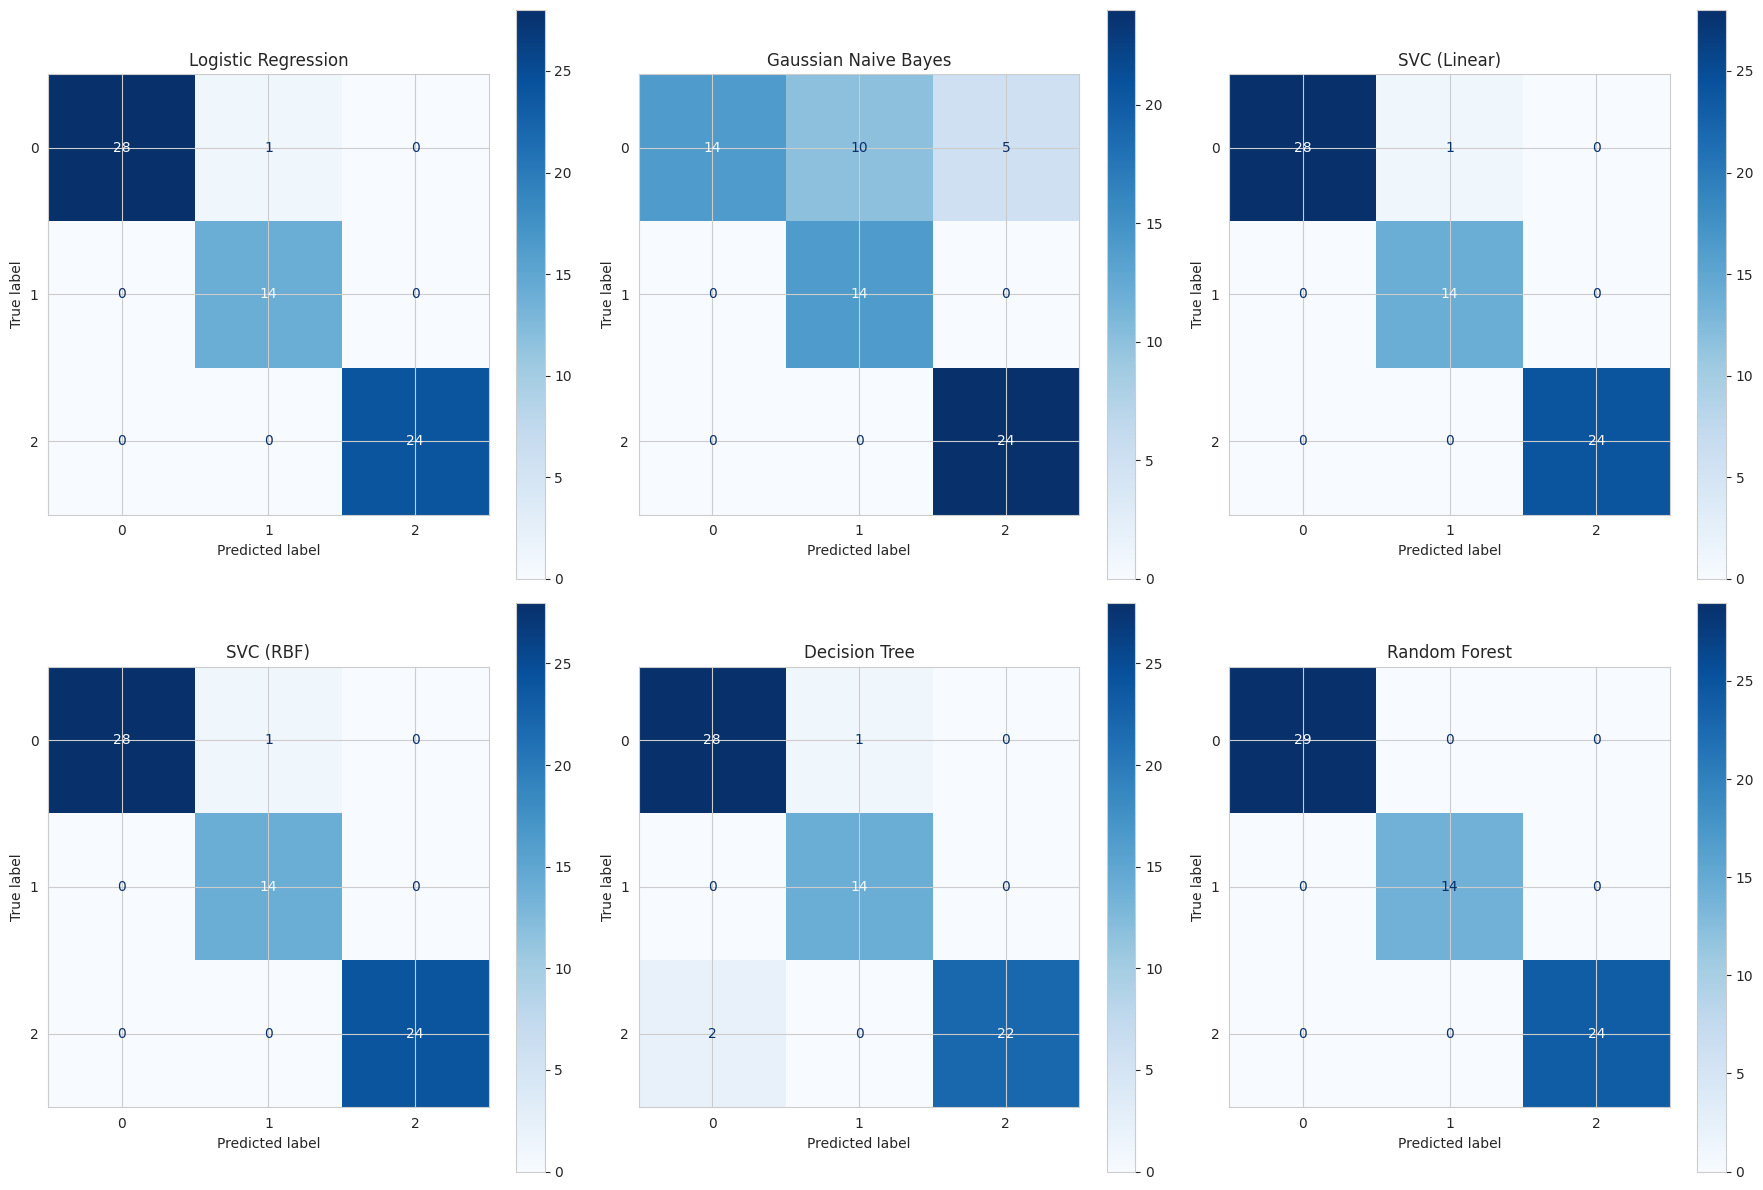

In [145]:
conf_mat_log_reg = confusion_matrix(y_test, y_pred_log_reg)
conf_mat_gnb = confusion_matrix(y_test, y_pred_gnb)
conf_mat_svc_lin = confusion_matrix(y_test, y_pred_svc_lin)
conf_mat_svc_rbf = confusion_matrix(y_test, y_pred_svc_rbf)
conf_mat_decision_tree = confusion_matrix(y_test, y_pred_decision_tree)
conf_mat_rand_for = confusion_matrix(y_test, y_pred_rand_for)

plt.subplots(2, 3, figsize=(18, 12))
ConfusionMatrixDisplay(conf_mat_log_reg, display_labels=log_reg.classes_).plot(ax=plt.subplot(2, 3, 1), cmap='Blues')
plt.title("Logistic Regression")
ConfusionMatrixDisplay(conf_mat_gnb, display_labels=GNB.classes_).plot(ax=plt.subplot(2, 3, 2), cmap='Blues')
plt.title("Gaussian Naive Bayes")
ConfusionMatrixDisplay(conf_mat_svc_lin, display_labels=svc_lin.classes_).plot(ax=plt.subplot(2, 3, 3), cmap='Blues')
plt.title("SVC (Linear)")
ConfusionMatrixDisplay(conf_mat_svc_rbf, display_labels=svc_rbf.classes_).plot(ax=plt.subplot(2, 3, 4), cmap='Blues')  
plt.title("SVC (RBF)")
ConfusionMatrixDisplay(conf_mat_decision_tree, display_labels=decision_tree.classes_).plot(ax=plt.subplot(2, 3, 5), cmap='Blues')  
plt.title("Decision Tree")
ConfusionMatrixDisplay(conf_mat_rand_for, display_labels=rand_for.classes_).plot(ax=plt.subplot(2, 3, 6), cmap='Blues')  
plt.title("Random Forest")
plt.tight_layout()
plt.show()

0 => ADELIE

1 => CHINSTRAP

2 => GENTOO

Random Forest - predicts everyone correctly

LogReg / SVC(rbf) / SVC(linear) - Makes 1 mistake, predicts Adelie as Chinstrap

Decision Tree - 1 misprediction of Adelie as Chinstrap and 2 of Gentoo as an Adelie

Gaussian Naive Bayes - 10 mispredictions of Adelie as Chinstrap and 5 of Adelie as Gentoo


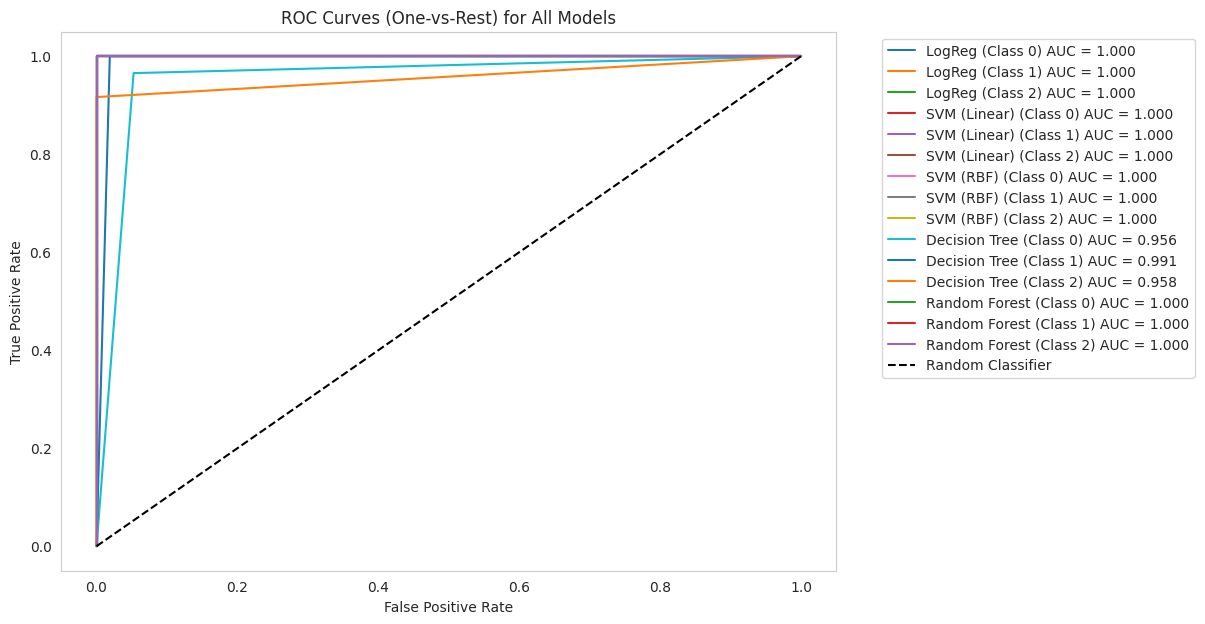

In [146]:
# ---- Binarize the target ----
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# ---- Models ----
models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "SVM (Linear)": SVC(kernel="linear", probability=True),
    "SVM (RBF)": SVC(kernel="rbf", probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
}

plt.figure(figsize=(10, 7))

# ---- Loop through models ----
for name, model in models.items():
    model.fit(X_train, y_train)

    # probability scores
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    else:
        y_score = model.decision_function(X_test)

    # ---- One-vs-Rest ROC per class ----
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, lw=1.5,
                 label=f"{name} (Class {i}) AUC = {roc_auc:.3f}")

# ---- Random baseline ----
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest) for All Models")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid()
plt.show()

## 1) Which model best balances precision and recall across all three species?

The best balance between precision and recall is achieved by **Logistic Regression** and **Support Vector Machines (Linear and RBF kernels)**.

These models consistently show high and stable weighted precision and recall scores (around 0.985), indicating that they perform well across all classes rather than favoring one species over the others. This suggests a good trade-off between false positives and false negatives.

Although Random Forest achieves perfect scores, it does not necessarily represent the best balance because its performance is maximized and may reflect model complexity rather than balanced generalization behavior.

---

## 2) Which species pair is hardest for the models to distinguish? Why might this be the case?

The hardest species pair to distinguish is:

- :contentReference[oaicite:0]{index=0}  
- :contentReference[oaicite:1]{index=1}  

This is because these two species have overlapping distributions in several key features such as bill length, bill depth, and body mass. Their morphological similarity makes it difficult for models to form a clear decision boundary between them.

As a result, small variations in these features can lead to misclassifications, which is reflected in the confusion matrices.

In contrast, :contentReference[oaicite:2]{index=2} is the easiest to classify due to its clearly distinct characteristics, especially larger flipper length and higher body mass, which create a well-separated cluster in feature space.

---

## 3) Based on confusion matrices and ROC curves, which model would you recommend?

Based on both confusion matrices and ROC curve analysis, the recommended model is **Logistic Regression**.

Even though Random Forest achieves perfect or near-perfect performance, Logistic Regression is preferred because:

- It provides consistently strong performance across all classes  
- It maintains a balanced trade-off between precision and recall  
- It shows stable ROC-AUC scores across all species  
- It is more interpretable and easier to explain  

Therefore, Logistic Regression offers the best combination of performance, stability, and interpretability for this classification task.


RandomForest and LogReg

In [147]:
import warnings
warnings.filterwarnings("ignore")

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10]
}

grid_search_rand_for = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted"
)
grid_search_rand_for.fit(X_train, y_train)
print("Best Hyperparameters for Random Forest:")
print(grid_search_rand_for.best_params_)
print('Best F1 Score:', grid_search_rand_for.best_score_)
print()


log_reg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=10000))
])

grid_search_log_reg = GridSearchCV(
    estimator=log_reg_pipeline,
    param_grid=[
        {
            "model__solver": ["lbfgs"],
            "model__penalty": ["l2"],
            "model__C": [0.01, 0.1, 1, 10]
        },
        {
            "model__solver": ["saga"],
            "model__penalty": ["l1", "l2"],
            "model__C": [0.01, 0.1, 1, 10]
        }
    ],
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search_log_reg.fit(X_train, y_train)
print("Best Hyperparameters for Logistic Regression:")
print(grid_search_log_reg.best_params_)
print('Best F1 Score:', grid_search_log_reg.best_score_)

Best Hyperparameters for Random Forest:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best F1 Score: 0.9961656161968262

Best Hyperparameters for Logistic Regression:
{'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best F1 Score: 0.9961656161968262


In [148]:
best_rf = grid_search_rand_for.best_estimator_
best_lr = grid_search_log_reg.best_estimator_

for name, model in [("Tuned RF", best_rf), ("Tuned LR", best_lr)]:
    y_pred = model.predict(X_test)
    print(name)
    print("F1:", f1_score(y_test, y_pred, average="weighted"))
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print()

Tuned RF
F1: 1.0
Accuracy: 1.0

Tuned LR
F1: 0.9852010365594893
Accuracy: 0.9850746268656716



Both Random Forest and LogReg cannot be improved, they performed best by default for this dataset

The improvement from hyperparameter tuning was not significant in a practical sense. Although the cross-validation F1 scores were already extremely high (~0.996), the test set performance did not improve meaningfully compared to the default models. In the case of Random Forest, the tuned model even achieved a perfect score on the test set, but this does not necessarily indicate a real improvement — it is more likely due to the dataset being small and highly separable, where even default parameters already capture the structure extremely well. For Logistic Regression, the tuned and default performance remain very close, showing that the model was already near its optimal configuration.

There is a moderate risk of overfitting to the validation folds during hyperparameter tuning. GridSearchCV evaluates many parameter combinations and selects the one that performs best on the cross-validation splits. This can lead to a situation where the chosen parameters are slightly tailored to the specific fold structure rather than representing a truly universally optimal configuration. However, in this case, the risk is limited because the dataset is small, clean, and well-separated, so model variance is naturally low.

Hyperparameter tuning is most impactful when models are sensitive to parameter changes and the baseline performance is not already near the maximum. It is especially useful in more complex or noisy datasets where decision boundaries are not clearly separable. Models such as SVMs, gradient boosting methods, and neural networks typically benefit more from tuning than simpler linear models or already stable ensemble models on easy datasets. In contrast, when data is highly structured and separable (as in this dataset), tuning provides only marginal gains and mainly serves to confirm robustness rather than improve accuracy significantly.